# Kalman innovation as an uncertainty feature

**Objective 2, exploration 1.** Objective 1 reproduced the ankle paper's gait-phase ensemble on
hip data: it reached J = 37.5 / AUROC 0.859 against held-out ambulation modes, catching standing
perfectly and missing stair ascent almost entirely. This notebook asks whether a
*model-based* uncertainty signal — derived from a Kalman filter fusing the hip encoder with the
IMU — adds anything the ensemble does not already provide.

## Why this might work

The hip exoskeleton measures the same joint twice, by unrelated physics:

- the **encoder**, measuring the actuator angle across the joint directly;
- the **IMU pair**, whose thigh-minus-pelvis angular rate implies the same joint's motion.

Under normal operation these agree. A Kalman filter that fuses them predicts each measurement
before seeing it, and the gap between prediction and observation — the **innovation** — is
normalised by the filter's own predicted covariance to give the **Normalised Innovation
Squared**:

$$\mathrm{NIS} = \nu^\top S^{-1} \nu, \qquad \nu = z - h(\hat{x}^-), \qquad S = HP^-H^\top + R$$

Its appeal is calibration. Under a correctly specified model NIS is $\chi^2$-distributed with
known degrees of freedom, so "surprising" has an absolute meaning rather than a learned
threshold — unlike the ensemble's variance, which is only interpretable relative to its own
training distribution.

## How this notebook proceeds

It is a record of an investigation, including the parts that did not work, because each failure
narrowed what the next attempt had to fix.

| Part | Question | Outcome |
|---|---|---|
| 1 | Setup and does the redundancy hold? | yes, r ≈ 0.95 |
| 2 | Filter v1 — both sensors as measurements | **fails**: NIS tracks motion, AUROC 0.41 |
| 3 | Filter v2 — gyro as control input | **fails**: still matched by `abs(rate)` |
| 4 | Calibrate Q and R by maximum likelihood | **diagnostic**: consistency only at implausible values |
| 5 | Sensor faults, not unfamiliar movements | promising, but confounded by a broken threshold |
| 6 | What else does the filter expose? | **works**: matched statistics beat the ensemble |

The short version: NIS itself is the wrong statistic, and the useful signal was in the
innovation *sequence* all along.

---
## Part 1 — Setup

In [1]:
from __future__ import annotations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import minimize, minimize_scalar
from sklearn.metrics import roc_auc_score


def find_repo_root(marker: str = "data/molinaro-raw") -> Path:
    for d in [Path.cwd(), *Path.cwd().parents]:
        if (d / marker).is_dir():
            return d
    raise FileNotFoundError(marker)


REPO = find_repo_root()
RAW = REPO / "data" / "molinaro-raw"
CACHE = REPO / "data" / "cache"
SAMPLE_RATE_HZ = 200
DT = 1.0 / SAMPLE_RATE_HZ
inventory = pd.read_parquet(CACHE / "inventory.parquet")

# Sagittal-plane channels. Notebook 01 established that gyro y is the sagittal axis on both
# legs with a consistent sign across all 34 participants, and that the IMUs are not mirrored.
PELVIS_GYRO_SAG = "pelvis_gyro_y"
GYRO_TO_ENCODER_SIGN = -1.0          # gyro y is +flexion; the encoder is +extension
FILTER_CHANNELS = ["enc_angle_l", "enc_velo_l", "thigh_gyro_y_l",
                   "enc_angle_r", "enc_velo_r", "thigh_gyro_y_r", PELVIS_GYRO_SAG]

# The ensemble's participant split, reused so nothing here is tuned on its evaluation set.
TRAIN_SUBJECTS = ["AB15","AB17","AB18","AB19","AB21","AB23","AB25","AB26","AB27","AB28","AB31","AB34"]
TEST_SUBJECTS = ["AB16", "AB24", "AB29", "AB30"]
ID_MODES, OOD_MODES = ("LG", "RA", "RD"), ("SA", "SD", "ST", "TR")

print(f"repo {REPO.name} | {len(inventory):,} trials indexed | {SAMPLE_RATE_HZ} Hz")

repo Uncertainty-Aware-Hip-Exoskeleton | 5,364 trials indexed | 200 Hz


In [2]:
def load_trial(subject: str, trial: str, channels=None) -> pd.DataFrame:
    """One trial as a continuous, time-ordered series.

    Unlike the windowed arrays of Objective 1, gaps are left in place: a recursive filter must
    know when a measurement is unavailable rather than have it quietly removed.
    """
    cols = ["time"] + (list(channels) if channels is not None else FILTER_CHANNELS)
    df = pd.read_csv(RAW / subject / trial / "exo.csv", usecols=cols)[cols]
    df["t"] = df["time"] - df["time"].iloc[0]
    return df


def relative_rate(df: pd.DataFrame, side: str = "l") -> np.ndarray:
    """IMU-derived hip angular rate, sign-corrected into the encoder's convention."""
    return GYRO_TO_ENCODER_SIGN * (
        df[f"thigh_gyro_y_{side}"].to_numpy(float) - df[PELVIS_GYRO_SAG].to_numpy(float))


pool = inventory.query("complete and phase in [3,4] and exo_hardware=='custom' "
                       "and mode in @ID_MODES and duration_s >= 30")
demo = pool.query("mode == 'LG'").iloc[0]
trial = load_trial(demo.subject, demo.trial)
print(f"demo trial: {demo.subject} / {demo.trial}  "
      f"({len(trial):,} samples, {trial['t'].iloc[-1]:.0f} s)")

demo trial: AB15 / LG_C0p0_S0p75_UC_1  (6,400 samples, 32 s)


### Does the redundancy actually hold?

Before building anything on the assumption that two sensors measure the same joint, check it.

hip angular velocity, two independent routes (left leg):
  corr(encoder, thigh-pelvis)  : +0.9432
  residual mean / std (rad/s)  : -0.0427 / 0.5736
  encoder velocity std (rad/s) : 1.5797
  residual as % of signal      : 36.3%

The residual is not noise to be filtered away -- it is the disagreement NIS normalises.


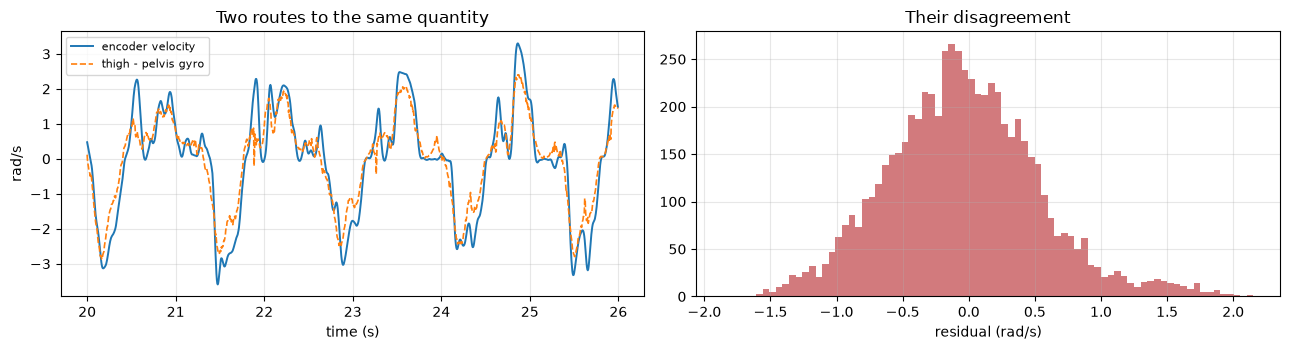

In [3]:
enc_v = trial["enc_velo_l"].to_numpy()
imu_v = relative_rate(trial, "l")
ok = np.isfinite(enc_v) & np.isfinite(imu_v)
resid = enc_v[ok] - imu_v[ok]

print(f"hip angular velocity, two independent routes (left leg):")
print(f"  corr(encoder, thigh-pelvis)  : {np.corrcoef(enc_v[ok], imu_v[ok])[0,1]:+.4f}")
print(f"  residual mean / std (rad/s)  : {resid.mean():+.4f} / {resid.std():.4f}")
print(f"  encoder velocity std (rad/s) : {enc_v[ok].std():.4f}")
print(f"  residual as % of signal      : {100*resid.std()/enc_v[ok].std():.1f}%")

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
m = (trial["t"] >= 20) & (trial["t"] < 26)
ax[0].plot(trial.loc[m, "t"], enc_v[m], lw=1.4, label="encoder velocity")
ax[0].plot(trial.loc[m, "t"], imu_v[m], lw=1.2, ls="--", label="thigh - pelvis gyro")
ax[0].set_xlabel("time (s)"); ax[0].set_ylabel("rad/s"); ax[0].legend(fontsize=8)
ax[0].set_title("Two routes to the same quantity"); ax[0].grid(alpha=0.3)
ax[1].hist(resid, bins=80, color="#C44E52", alpha=0.75)
ax[1].set_xlabel("residual (rad/s)"); ax[1].set_title("Their disagreement")
ax[1].grid(alpha=0.3)
fig.tight_layout()
print("\nThe residual is not noise to be filtered away -- it is the disagreement NIS normalises.")

---
## Part 2 — Filter v1: both sensors as measurements

**State** $x=[\theta,\omega,b]$, **measurements** $z=[\theta_\text{enc},\,\omega_\text{imu}]$,
constant-velocity process with a random-walk bias. Both sensors are measurements of a shared
state, so the innovation reflects disagreement between them. $\dim z = 2$, so a consistent
filter gives $\mathrm{NIS}\sim\chi^2_2$.

### The EKF step

The model here is linear, so `F` and `H` are constant and this is a plain Kalman filter. The
EKF structure is kept because the natural extension — gravity-referenced inclination from the
accelerometers, needing $\arctan$ — is nonlinear, and that change should touch only the model
functions.

Three implementation details that matter over a 24,000-step trial:

1. **Joseph-form covariance update.** $(I-KH)P$ is algebraically correct but loses symmetry and
   positive-definiteness to floating-point error; $(I-KH)P(I-KH)^\top+KRK^\top$ does not.
2. **No explicit inverse.** `solve(S, I)` is an inverse by another name. Solving
   $S^\top K^\top=(PH^\top)^\top$ avoids forming one.
3. **Missing measurements.** These recordings contain NaN gaps; the filter must predict through
   them rather than let a NaN into the state, where it would stay forever.

In [4]:
def ekf_step(x_prev, P_prev, u, z, dt, Q, R, f=None, F_fn=None, h=None, H_fn=None):
    """One predict/correct cycle. Returns (posterior state, posterior covariance, NIS).

    NIS uses the *prior* innovation, before the correction -- it measures how surprising the
    measurement was given the model, which is the entire point. A NaN in `z` skips the update.
    """
    x_pred = f(x_prev, u, dt)
    F = F_fn(x_prev, u, dt)
    P_pred = F @ P_prev @ F.T + Q
    P_pred = 0.5 * (P_pred + P_pred.T)

    if z is None or np.isnan(z).any():
        return x_pred, P_pred, np.nan

    y = z - h(x_pred)
    H = H_fn(x_pred)
    S = 0.5 * ((H @ P_pred @ H.T + R) + (H @ P_pred @ H.T + R).T)
    nis = float(y @ np.linalg.solve(S, y))

    K = np.linalg.solve(S.T, (P_pred @ H.T).T).T        # K = P H^T S^-1, no inverse formed
    x_upd = x_pred + K @ y
    A = np.eye(len(x_prev)) - K @ H
    P_upd = A @ P_pred @ A.T + K @ R @ K.T              # Joseph form
    return x_upd, 0.5 * (P_upd + P_upd.T), nis


# ---- v1 model ------------------------------------------------------------------
f_v1 = lambda x, u, dt: np.array([x[0] + dt * x[1], x[1], x[2]])
F_v1 = lambda x, u, dt: np.array([[1., dt, 0.], [0., 1., 0.], [0., 0., 1.]])
h_v1 = lambda x: np.array([x[0], x[1] + x[2]])
H_v1 = lambda x: np.array([[1., 0., 0.], [0., 1., 1.]])

SIGMA_ENC_ANGLE, SIGMA_IMU_RATE = 0.005, 0.10      # rad, rad/s   -- NOMINAL
SIGMA_ACCEL, SIGMA_BIAS = 50.0, 1e-3               # rad/s^2, rad/s/sqrt(s)  -- NOMINAL

def make_Q_v1(dt, sa=SIGMA_ACCEL, sb=SIGMA_BIAS):
    Q = np.zeros((3, 3))
    Q[:2, :2] = sa ** 2 * np.array([[dt**4/4, dt**3/2], [dt**3/2, dt**2]])
    Q[2, 2] = sb ** 2 * dt
    return Q

R_V1, Q_V1 = np.diag([SIGMA_ENC_ANGLE**2, SIGMA_IMU_RATE**2]), make_Q_v1(DT)
BOUND95_2 = stats.chi2.ppf(0.95, df=2)


def run_v1(df, side="l", Q=Q_V1, R=R_V1, x0=None, P0=None):
    th = df[f"enc_angle_{side}"].to_numpy(float)
    om = relative_rate(df, side)
    x = np.array([th[0] if np.isfinite(th[0]) else 0., 0., 0.]) if x0 is None else np.asarray(x0, float)
    P = np.diag([0.01, 1.0, 0.01]) if P0 is None else np.asarray(P0, float)
    X = np.full((len(th), 3), np.nan); NIS = np.full(len(th), np.nan)
    for k in range(len(th)):
        x, P, n = ekf_step(x, P, None, np.array([th[k], om[k]]), DT, Q, R,
                           f=f_v1, F_fn=F_v1, h=h_v1, H_fn=H_v1)
        X[k], NIS[k] = x, n
    return pd.DataFrame({"t": df["t"].to_numpy(), "theta": X[:,0], "omega": X[:,1],
                         "bias": X[:,2], "nis": NIS, "rate": om})


r1 = run_v1(trial)
v = r1["nis"].notna()
print(f"v1 on the demo trial: NIS median {r1.nis.median():.2f}  mean {r1.nis.mean():.2f}"
      f"   (chi-squared(2) expects 1.39 / 2.00)")
print(f"  above the 95th percentile ({BOUND95_2:.2f}): {100*(r1.loc[v,'nis']>BOUND95_2).mean():.1f}%"
      f"   -- a consistent filter gives ~5%")
print("\nThe filter is far too optimistic. Whether that is a tuning problem or a modelling")
print("problem is the question Part 4 settles.")

v1 on the demo trial: NIS median 2.46  mean 8.10   (chi-squared(2) expects 1.39 / 2.00)
  above the 95th percentile (5.99): 30.8%   -- a consistent filter gives ~5%

The filter is far too optimistic. Whether that is a tuning problem or a modelling
problem is the question Part 4 settles.


### NIS by task — and a confound that had to be handled first

Trial durations are wildly unequal: treadmill locomotion runs 32 s, but the overground stair
trials are only ~5.5 s. The filter's bias state needs seconds to converge and NIS is inflated
while it does, so run naively, stairs would score as uncertain **because they are short**. Two
corrections: warm-start the bias per participant from their own level-ground data, and run a
duration-matched control.

In [5]:
WARMUP_S = 1.0

def converged_bias(subject, side="l"):
    lg = inventory.query("complete and subject == @subject and mode == 'LG' and duration_s >= 30")
    if not len(lg):
        return 0.0
    r = run_v1(load_trial(lg.iloc[0].subject, lg.iloc[0].trial), side=side)
    return float(r["bias"].iloc[-int(len(r) * 0.25):].median())


def pool_nis_v1(trials, bias, side="l", truncate_s=None):
    out = []
    for r in trials.itertuples():
        df = load_trial(r.subject, r.trial)
        if truncate_s is not None:
            df = df[df["t"] < truncate_s]
        b0 = bias.get(r.subject, 0.0)
        th0 = df[f"enc_angle_{side}"].iloc[0]
        res = run_v1(df, side=side, x0=[th0 if np.isfinite(th0) else 0., 0., b0],
                     P0=np.diag([0.01, 1.0, 1e-4]))
        k = ((res["t"] >= WARMUP_S) & res["nis"].notna()).to_numpy()
        if k.sum():
            out.append(pd.DataFrame({"nis": res["nis"].to_numpy()[k], "mode": r.mode,
                                     "kind": "OOD" if r.mode in OOD_MODES else "ID"}))
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()


sel = inventory.query("complete and phase in [3,4] and exo_hardware=='custom' "
                      "and subject in @TEST_SUBJECTS and duration_s >= 3")
BIAS = {s: converged_bias(s) for s in TEST_SUBJECTS}
nis1 = pool_nis_v1(sel, BIAS)
print(f"{len(sel)} trials -> {len(nis1):,} NIS samples")
display(nis1.groupby(["kind", "mode"], observed=True)["nis"]
        .agg(samples="size", median="median",
             pct_above=lambda s: 100 * (s > BOUND95_2).mean()).round(2))

y = (nis1["kind"] == "OOD").astype(int)
auc_full = roc_auc_score(y, nis1["nis"])
id_tr = pool_nis_v1(sel[sel["mode"].isin(ID_MODES)], BIAS, truncate_s=5.6)
ctrl = pd.concat([id_tr, nis1[nis1["kind"] == "OOD"]], ignore_index=True)
auc_ctrl = roc_auc_score((ctrl["kind"] == "OOD").astype(int), ctrl["nis"])
print(f"AUROC, ID vs OOD          : {auc_full:.3f}")
print(f"AUROC, duration-matched   : {auc_ctrl:.3f}   (change {auc_ctrl-auc_full:+.3f})")
print("-> not a trial-length artefact." if abs(auc_ctrl-auc_full) < 0.03 else "-> length matters.")

303 trials -> 847,912 NIS samples


samples  median  pct_above
kind mode                            
ID   LG     286281   10.08      60.12
     RA     184804   14.60      66.54
     RD     147600    6.90      52.85
OOD  SA     102193    9.13      58.34
     SD     100925    5.93      49.79
     ST       6200    0.00       0.00
     TR      19909    0.68      23.21

AUROC, ID vs OOD          : 0.413
AUROC, duration-matched   : 0.424   (change +0.011)
-> not a trial-length artefact.


Standing — the most obviously unfamiliar task — has the LOWEST uncertainty of all.
Both sensors read ~zero and agree perfectly, so there is nothing to be surprised by.


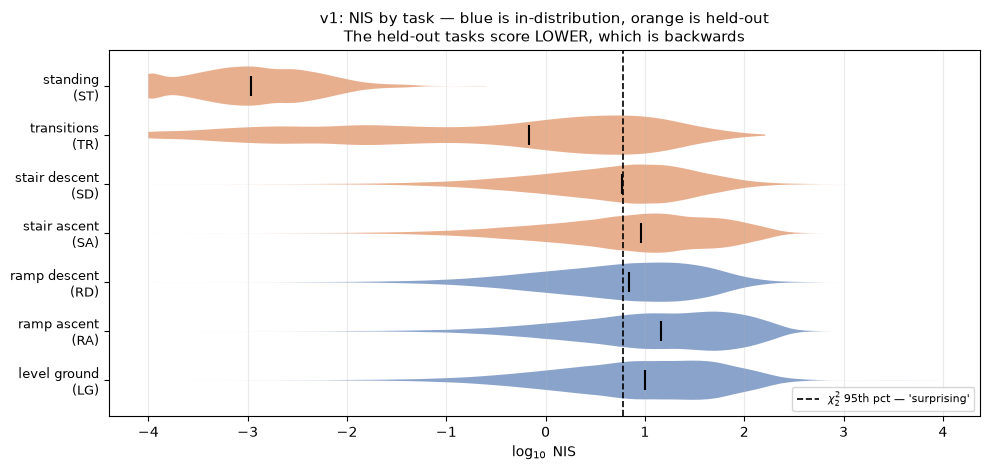

In [6]:
# SCRUB_MARKER -- what the v1 failure looks like
order=[m for m in ("LG","RA","RD","SA","SD","TR","ST") if (nis1["mode"]==m).any()]
NAMES={"LG":"level ground","RA":"ramp ascent","RD":"ramp descent","SA":"stair ascent",
       "SD":"stair descent","ST":"standing","TR":"transitions"}
C_ID,C_OOD="#4C72B0","#DD8452"
fig,ax=plt.subplots(figsize=(10,4.8))
for i,mo in enumerate(order):
    s=np.clip(nis1.loc[nis1["mode"]==mo,"nis"].to_numpy(),1e-4,None)
    p=ax.violinplot([np.log10(s)],positions=[i],orientation="horizontal",widths=0.8,
                    showextrema=False,showmedians=True)
    for b in p["bodies"]:
        b.set_facecolor(C_OOD if mo in OOD_MODES else C_ID); b.set_alpha(0.65); b.set_edgecolor("none")
    p["cmedians"].set_color("black")
ax.axvline(np.log10(BOUND95_2),color="k",ls="--",lw=1.2,
           label=r"$\chi^2_2$ 95th pct — 'surprising'")
ax.set_yticks(range(len(order))); ax.set_yticklabels([f"{NAMES[m]}\n({m})" for m in order],fontsize=9)
ax.set_xlabel(r"$\log_{10}$ NIS"); ax.legend(fontsize=8,loc="lower right"); ax.grid(alpha=0.25,axis="x")
ax.set_title("v1: NIS by task — blue is in-distribution, orange is held-out\n"
             "The held-out tasks score LOWER, which is backwards",fontsize=11)
fig.tight_layout()
print("Standing — the most obviously unfamiliar task — has the LOWEST uncertainty of all.")
print("Both sensors read ~zero and agree perfectly, so there is nothing to be surprised by.")

### Result: v1 fails, and instructively

AUROC **below 0.5** means NIS is anti-correlated with novelty — the held-out tasks score
*lower* than familiar walking, and standing scores lowest of all.

The reason is visible once stated. During standing both sensors read near zero and agree
perfectly, so the innovation vanishes. During vigorous walking the constant-velocity model is
badly wrong, so the innovation is large. **NIS here measures how hard the joint is moving, not
how unfamiliar the movement is.** It is dominated by process-model error.

That diagnosis is what motivates Part 3.

---
## Part 3 — Filter v2: gyro as control input

Move the gyro into the process model. The state then propagates on the *measured* rate, so the
model only has to integrate correctly — which it can — and what remains in the innovation is
the encoder disagreeing with the integrated gyro: genuine sensor disagreement.

$$x=\begin{bmatrix}\theta\\b\end{bmatrix},\quad u=\omega_\text{imu},\quad
f(x,u)=\begin{bmatrix}\theta+\Delta t\,(u-b)\\b\end{bmatrix},\quad
F=\begin{bmatrix}1&-\Delta t\\0&1\end{bmatrix}$$

$$z=\theta_\text{enc},\quad h(x)=\theta,\quad H=\begin{bmatrix}1&0\end{bmatrix},
\qquad \mathrm{NIS}\sim\chi^2_1$$

Encoder *velocity* is deliberately excluded as a second measurement: the dataset derives it from
encoder position by finite differencing, so it carries no independent information.

From here on a scalar implementation of this specific filter is used instead of the general
`ekf_step` — same algebra, roughly 20x faster, which the optimiser in Part 4 needs.

In [7]:
def filt(th, om, q00, q11, r, want="nis"):
    """Scalar 2-state / 1-measurement KF with Joseph update.

    Returns the NIS series, or the log-likelihood, or the full diagnostic set. Identical
    algebra to ekf_step with the v2 model, written out for speed.
    """
    n = len(th)
    x = th[0] if np.isfinite(th[0]) else 0.0
    xb = 0.0
    p00, p01, p11 = 0.01, 0.0, 0.01
    ll = 0.0
    NIS = np.full(n, np.nan); Y = np.full(n, np.nan)
    S_ = np.full(n, np.nan); B = np.full(n, np.nan)
    for k in range(n):
        u = om[k] if np.isfinite(om[k]) else 0.0
        x = x + DT * (u - xb)                                   # predict
        pp00 = p00 - 2*DT*p01 + DT*DT*p11 + q00
        pp01 = p01 - DT*p11
        pp11 = p11 + q11
        z = th[k]
        if not np.isfinite(z):
            p00, p01, p11 = pp00, pp01, pp11; B[k] = xb; continue
        S = pp00 + r
        y = z - x
        NIS[k], Y[k], S_[k] = y*y/S, y, S
        ll += -0.5 * (np.log(2*np.pi) + np.log(S) + y*y/S)
        K0, K1 = pp00/S, pp01/S                                 # update
        x += K0*y; xb += K1*y
        a = 1.0 - K0
        p00 = a*a*pp00 + r*K0*K0
        p01 = a*(pp01 - K1*pp00) + r*K0*K1
        p11 = K1*K1*pp00 - 2*K1*pp01 + pp11 + r*K1*K1
        B[k] = xb
    if want == "ll":   return ll
    if want == "all":  return NIS, Y, S_, B
    return NIS


SIGMA_GYRO_NOM = 0.10                                   # rad/s, NOMINAL
Q00_NOM, Q11_NOM, R_NOM = (SIGMA_GYRO_NOM*DT)**2, SIGMA_BIAS**2*DT, SIGMA_ENC_ANGLE**2
BOUND95_1 = stats.chi2.ppf(0.95, df=1)

th_d = trial["enc_angle_l"].to_numpy(float); om_d = relative_rate(trial, "l")
n2 = filt(th_d, om_d, Q00_NOM, Q11_NOM, R_NOM)
ok = np.isfinite(n2)
print(f"v2 on the demo trial: NIS median {np.median(n2[ok]):.2f}  mean {n2[ok].mean():.2f}"
      f"   (chi-squared(1) expects 0.45 / 1.00)")
print(f"  above the 95th percentile ({BOUND95_1:.2f}): {100*(n2[ok]>BOUND95_1).mean():.1f}%")

v2 on the demo trial: NIS median 2.32  mean 7.86   (chi-squared(1) expects 0.45 / 1.00)
  above the 95th percentile (3.84): 40.2%


### Acceptance test: does NIS beat a trivial motion feature?

This is the bar. If NIS is matched by `abs(hip rate)`, the filter is an expensive way to compute
something free.

In [8]:
def pool_v2(trials, side="l"):
    out = []
    for r in trials.itertuples():
        df = load_trial(r.subject, r.trial)
        th = df[f"enc_angle_{side}"].to_numpy(float); om = relative_rate(df, side)
        nis = filt(th, om, Q00_NOM, Q11_NOM, R_NOM)
        k = ((df["t"] >= WARMUP_S).to_numpy()) & np.isfinite(nis)
        if k.sum():
            out.append(pd.DataFrame({"nis": nis[k], "rate": np.abs(om[k]), "mode": r.mode,
                                     "kind": "OOD" if r.mode in OOD_MODES else "ID"}))
    return pd.concat(out, ignore_index=True)


sel2 = (inventory.query("complete and phase in [3,4] and exo_hardware=='custom' and duration_s>=3")
        .sample(frac=1.0, random_state=0).groupby("mode", observed=True).head(8))
nis2 = pool_v2(sel2)
best = lambda yy, s: max(roc_auc_score(yy, s), roc_auc_score(yy, -s))

display(nis2.groupby(["kind", "mode"], observed=True)
        .agg(samples=("nis","size"), median_nis=("nis","median"),
             median_rate=("rate","median")).round(3))

print(f"{'target':24s} {'AUROC(NIS)':>11s} {'AUROC(|rate|)':>14s} {'advantage':>10s}")
for tgt in OOD_MODES:
    if (nis2["mode"] == tgt).sum() == 0: continue
    s = (nis2["mode"].isin(ID_MODES) | (nis2["mode"] == tgt)).to_numpy()
    yy = (nis2.loc[s, "mode"] == tgt).astype(int).to_numpy()
    a_n = best(yy, nis2.loc[s, "nis"].to_numpy()); a_r = best(yy, nis2.loc[s, "rate"].to_numpy())
    print(f"{tgt + ' vs locomotion':24s} {a_n:11.3f} {a_r:14.3f} {a_n-a_r:+10.3f}")

samples  median_nis  median_rate
kind mode                                  
ID   LG      85604      14.850        1.269
     RA      67602      10.377        1.573
     RD      49600       8.456        0.722
OOD  SA       7298      18.133        1.461
     SD       7381       6.766        0.830
     ST      31000       0.001        0.026
     TR      33805       0.851        0.228

target                    AUROC(NIS)  AUROC(|rate|)  advantage
SA vs locomotion               0.560          0.552     +0.008
SD vs locomotion               0.574          0.602     -0.028


ST vs locomotion               0.991          0.989     +0.002
TR vs locomotion               0.728          0.741     -0.013


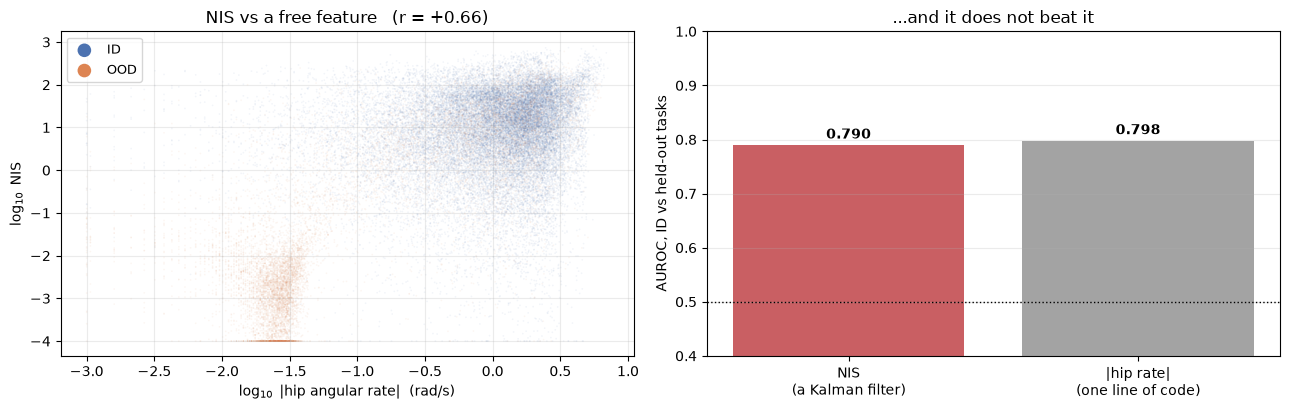

In [9]:
# SCRUB_MARKER -- why: NIS is re-deriving motion magnitude
sub=nis2.sample(min(40000,len(nis2)),random_state=0)
fig,ax=plt.subplots(1,2,figsize=(13,4.2))
for kind,col in (("ID",C_ID),("OOD",C_OOD)):
    d_=sub[sub["kind"]==kind]
    ax[0].scatter(np.log10(np.clip(d_["rate"],1e-3,None)),np.log10(np.clip(d_["nis"],1e-4,None)),
                  s=1.5,alpha=0.07,c=col,edgecolors="none",rasterized=True,label=kind)
r_=np.log10(np.clip(sub["rate"],1e-3,None)); n_=np.log10(np.clip(sub["nis"],1e-4,None))
ax[0].set_xlabel(r"$\log_{10}$ |hip angular rate|  (rad/s)")
ax[0].set_ylabel(r"$\log_{10}$ NIS")
ax[0].set_title(f"NIS vs a free feature   (r = {np.corrcoef(r_,n_)[0,1]:+.2f})")
lg=ax[0].legend(fontsize=9,markerscale=8)
for h in lg.legend_handles: h.set_alpha(1)
ax[0].grid(alpha=0.25)

y_=(nis2["kind"]=="OOD").astype(int).to_numpy()
bars=[best(y_,nis2["nis"].to_numpy()),best(y_,nis2["rate"].to_numpy())]
ax[1].bar(["NIS\n(a Kalman filter)","|hip rate|\n(one line of code)"],bars,
          color=["#C44E52","#999999"],alpha=0.9)
for i,b in enumerate(bars): ax[1].text(i,b+0.012,f"{b:.3f}",ha="center",fontweight="bold")
ax[1].axhline(0.5,color="k",ls=":",lw=1); ax[1].set_ylim(0.4,1.0)
ax[1].set_ylabel("AUROC, ID vs held-out tasks")
ax[1].set_title("...and it does not beat it"); ax[1].grid(alpha=0.25,axis="y")
fig.tight_layout()

autocorrelation outside the white band: 88% of lags (white: ~5%)
gait-locked swing 0.05780 rad vs innovation std 0.01474 rad  -> ratio 3.92


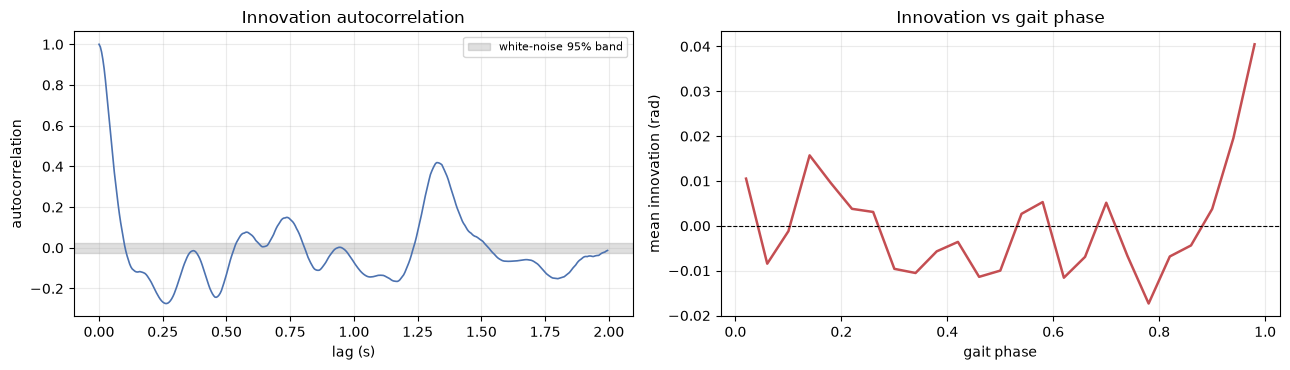

In [10]:
# Why: is the innovation white, or still structured by gait?
_, Y, _, _ = filt(th_d, om_d, Q00_NOM, Q11_NOM, R_NOM, want="all")
yc = Y[np.isfinite(Y)]; yc = yc - yc.mean()
maxlag = 400
ac = np.array([1.0] + [np.corrcoef(yc[:-k], yc[k:])[0,1] for k in range(1, maxlag)])
conf = 1.96 / np.sqrt(len(yc))

gp = pd.read_csv(RAW / demo.subject / demo.trial / "gp.csv", usecols=["gp_hs_l"])
ph = gp["gp_hs_l"].to_numpy()[:len(Y)]; iv = Y[:len(ph)]
g = np.isfinite(ph) & np.isfinite(iv)
bins = np.linspace(0, 1, 26); bi = np.digitize(ph[g], bins) - 1
prof = np.array([iv[g][bi==b].mean() if (bi==b).any() else np.nan for b in range(25)])

fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
ax[0].plot(np.arange(maxlag)*DT, ac, lw=1.2, color="#4C72B0")
ax[0].axhspan(-conf, conf, color="grey", alpha=0.25, label="white-noise 95% band")
ax[0].set_xlabel("lag (s)"); ax[0].set_ylabel("autocorrelation")
ax[0].set_title("Innovation autocorrelation"); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.25)
ax[1].plot(0.5*(bins[:-1]+bins[1:]), prof, lw=1.8, color="#C44E52")
ax[1].axhline(0, color="k", lw=0.8, ls="--")
ax[1].set_xlabel("gait phase"); ax[1].set_ylabel("mean innovation (rad)")
ax[1].set_title("Innovation vs gait phase"); ax[1].grid(alpha=0.25)
fig.tight_layout()

print(f"autocorrelation outside the white band: {100*np.mean(np.abs(ac[1:])>conf):.0f}% of lags (white: ~5%)")
print(f"gait-locked swing {np.nanmax(prof)-np.nanmin(prof):.5f} rad vs innovation std "
      f"{np.nanstd(iv):.5f} rad  -> ratio {(np.nanmax(prof)-np.nanmin(prof))/np.nanstd(iv):.2f}")

### Result: v2 also fails, and now we know why

Still matched by `abs(hip rate)`. The whiteness test explains it: the innovation remains
strongly gait-structured, with a phase-locked swing several times its own standard deviation.
Something systematic separates the encoder angle from the integrated thigh-minus-pelvis rate
over a stride — soft-tissue motion, frame misalignment, or a real kinematic difference between
what the encoder measures across the joint and what the two gyros imply.

A structured innovation is a **modelling** failure, not a tuning one. Part 4 confirms that
independently.

---
## Part 4 — Calibrating Q and R by maximum likelihood

Two things to establish here. First, that tuning **cannot** rescue the discrimination — NIS is
invariant to uniform scaling of $Q$ and $R$, so the ordering between tasks is fixed no matter
what values are chosen. Second, what a proper fit reveals about the model.

Maximum likelihood maximises the probability of the observed measurements under the filter's own
predicted distributions:

$$\log L = -\tfrac{1}{2}\sum_k \left[\log 2\pi + \log S_k + \nu_k^2/S_k\right]$$

Fitted on **training participants only**, so nothing here sees the evaluation set.

In [11]:
# --- scale invariance: does tuning move the discrimination at all? ---------------
probe = (inventory.query("complete and phase in [3,4] and exo_hardware=='custom' and duration_s>=3")
         .sample(frac=1.0, random_state=0).groupby("mode", observed=True).head(4))
rows = []
for c in (0.1, 1.0, 10.0):
    p = []
    for r in probe.itertuples():
        df = load_trial(r.subject, r.trial)
        th = df["enc_angle_l"].to_numpy(float); om = relative_rate(df, "l")
        nis = filt(th, om, c*Q00_NOM, c*Q11_NOM, c*R_NOM)
        k = (df["t"] >= WARMUP_S).to_numpy() & np.isfinite(nis)
        p.append(pd.DataFrame({"nis": nis[k], "kind": "OOD" if r.mode in OOD_MODES else "ID"}))
    p = pd.concat(p, ignore_index=True)
    yy = (p["kind"] == "OOD").astype(int)
    rows.append({"Q,R scale": f"x{c:g}", "mean NIS": p["nis"].mean(),
                 "AUROC": best(yy, p["nis"].to_numpy())})
display(pd.DataFrame(rows).round(3))
print("Scaling Q and R together shifts every NIS value but leaves the ordering untouched,")
print("so AUROC is identical. Tuning changes calibration, never discrimination.")

,"Q,R scale",mean NIS,AUROC
0,x0.1,287.209,0.829
1,x1,28.721,0.829
2,x10,2.872,0.829


Scaling Q and R together shifts every NIS value but leaves the ordering untouched,
so AUROC is identical. Tuning changes calibration, never discrimination.


In [12]:
# --- MLE fit on training participants --------------------------------------------
fit_sel = (inventory.query("complete and phase in [3,4] and exo_hardware=='custom' "
                           "and subject in @TRAIN_SUBJECTS and mode in @ID_MODES and duration_s>=30")
           .sample(frac=1.0, random_state=0).groupby("mode", observed=True).head(2))
FITDATA = []
for r in fit_sel.itertuples():
    df = load_trial(r.subject, r.trial)
    FITDATA.append((df["enc_angle_l"].to_numpy(float), relative_rate(df, "l")))
print(f"fitting on {len(FITDATA)} training-participant trials "
      f"({sum(len(a) for a,_ in FITDATA):,} samples)")

def nll(logp):
    sg, sb, se = np.exp(logp)
    return -sum(filt(th, om, (sg*DT)**2, sb*sb*DT, se*se, want="ll") for th, om in FITDATA)

x0 = np.log([SIGMA_GYRO_NOM, SIGMA_BIAS, SIGMA_ENC_ANGLE])
res = minimize(nll, x0, method="Nelder-Mead", options={"xatol":1e-3,"fatol":1e-1,"maxiter":300})
SG_F, SB_F, SE_F = np.exp(res.x)
print(f"\n  nominal  sigma_gyro {SIGMA_GYRO_NOM:.4f}  sigma_b {SIGMA_BIAS:.2e}  sigma_enc {SIGMA_ENC_ANGLE:.5f}")
print(f"  MLE      sigma_gyro {SG_F:.4f}  sigma_b {SB_F:.2e}  sigma_enc {SE_F:.5f}")
print("\n  sigma_b is ~1000x a physical MEMS bias walk, and sigma_enc has collapsed to zero.")
print("  The optimiser did not find the physics -- it inflated process noise until the")
print("  model's own error was absorbed by the covariance.")

# constrained: hold the physically-known terms, fit only the gyro noise
rc = minimize_scalar(lambda lg: -sum(filt(th, om, (np.exp(lg)*DT)**2, SIGMA_BIAS**2*DT,
                                          SIGMA_ENC_ANGLE**2, want="ll") for th, om in FITDATA),
                     bounds=(np.log(0.01), np.log(50.0)), method="bounded")
SG_C = float(np.exp(rc.x))
print(f"\n  constrained MLE: sigma_gyro {SG_C:.4f} rad/s -- still {SG_C/SIGMA_GYRO_NOM:.0f}x plausible")

PARAMS = {"nominal":    (Q00_NOM, Q11_NOM, R_NOM),
          "MLE free":   ((SG_F*DT)**2, SB_F**2*DT, SE_F**2),
          "MLE constr": ((SG_C*DT)**2, SIGMA_BIAS**2*DT, SIGMA_ENC_ANGLE**2)}

chk = (inventory.query("complete and subject in @TEST_SUBJECTS and mode in @ID_MODES and duration_s>=30")
       .sample(frac=1.0, random_state=1).head(5))
CHK = []
for r in chk.itertuples():
    df = load_trial(r.subject, r.trial)
    CHK.append((df["enc_angle_l"].to_numpy(float), relative_rate(df, "l")))
print(f"\nconsistency on {len(CHK)} held-out trials (chi-squared(1): mean 1.00, ~5% above {BOUND95_1:.2f})")
for lbl, (q0, q1, r_) in PARAMS.items():
    vals = [filt(th, om, q0, q1, r_)[200:] for th, om in CHK]
    pool_ = np.concatenate([v[np.isfinite(v)] for v in vals])
    print(f"  {lbl:11s} mean {pool_.mean():8.3f}   above 95th pct {100*(pool_>BOUND95_1).mean():5.1f}%")

fitting on 6 training-participant trials (38,402 samples)



  nominal  sigma_gyro 0.1000  sigma_b 1.00e-03  sigma_enc 0.00500
  MLE      sigma_gyro 0.4407  sigma_b 4.30e+00  sigma_enc 0.00000

  sigma_b is ~1000x a physical MEMS bias walk, and sigma_enc has collapsed to zero.
  The optimiser did not find the physics -- it inflated process noise until the
  model's own error was absorbed by the covariance.



  constrained MLE: sigma_gyro 1.2056 rad/s -- still 12x plausible

consistency on 5 held-out trials (chi-squared(1): mean 1.00, ~5% above 3.84)
  nominal     mean   38.497   above 95th pct  71.5%
  MLE free    mean    1.294   above 95th pct   9.0%
  MLE constr  mean    0.655   above 95th pct   3.5%


### Result: consistency is reachable, but only at implausible parameters

The free fit achieves near-perfect calibration — and does so by declaring the encoder noiseless
and the gyro bias wildly unstable. Constrained to physical values for those, it still demands
about **12x** a plausible gyro noise.

That is the same conclusion the whiteness test reached, by an independent route: the process
model is mis-specified, and calibration spends its entire budget covering for that rather than
describing the sensors.

---
## Part 5 — Reframing: sensor faults, not unfamiliar movements

Three attempts at detecting unfamiliar *movement* have now failed. But that was never the
natural target for this signal. The ankle paper motivates uncertainty estimation partly by
faulty data — *"if the model receives data that is faulty (e.g., dropped sensor)"* — yet its
out-of-distribution set contains only unfamiliar movements, never a broken sensor.

That condition can be created in existing recordings at no collection cost.

| fault | injected as | physically |
|---|---|---|
| **dropout** | rate held at 0 | the gyro stops reporting |
| **gain** | rate x 1.5 | wrong full-scale range, or a **strap rotating** so less of the true rate projects onto the measured axis |
| **bias** | rate + 0.5 rad/s | turn-on offset, thermal drift |
| **latency** | rate delayed 100 ms | a comms hiccup delaying the sample stream |

Two honest caveats. The injected bias of 0.5 rad/s is **29 deg/s**, roughly 20x a real MEMS
turn-on bias — these are aggressive faults, so weak detection here implies weaker detection in
practice. And the fault is applied to the *derived* relative rate rather than to one physical
gyro, which is a simplification worth revisiting.

Note also that the filter estimates bias **as a state**, whose job is to absorb exactly this
kind of offset. NIS being poor at bias faults is structural, not a tuning failure.

In [13]:
T0, T1 = 12.0, 18.0        # fault window, seconds into the trial

def inject(rate, kind, t, **kw):
    """Corrupt the IMU-derived rate between T0 and T1. The movement itself is untouched."""
    o = rate.copy(); w = (t >= T0) & (t < T1)
    if kind == "none":      return o
    if kind == "dropout":   o[w] = 0.0
    elif kind == "gain":    o[w] *= kw.get("g", 1.5)
    elif kind == "bias":    o[w] += kw.get("off", 0.5)
    elif kind == "latency":
        s = kw.get("s", 20)
        o[w] = rate[np.clip(np.arange(len(rate)) - s, 0, len(rate)-1)][w]
    else: raise ValueError(kind)
    return o

FAULTS = [("dropout", {}), ("gain", {"g": 1.5}), ("bias", {"off": 0.5}), ("latency", {"s": 20})]

ft = inventory.query("complete and subject in @TEST_SUBJECTS and mode=='LG' and duration_s>=30").iloc[0]
fdf = load_trial(ft.subject, ft.trial)
t_f = fdf["t"].to_numpy(); th_f = fdf["enc_angle_l"].to_numpy(float); om_f = relative_rate(fdf, "l")
print(f"fault trial: {ft.subject}/{ft.trial}  ({len(t_f):,} samples), fault active {T0:.0f}-{T1:.0f}s\n")

rows = []
for lbl, (q0, q1, r_) in PARAMS.items():
    clean = filt(th_f, om_f, q0, q1, r_)
    bef = (t_f < T0) & (t_f >= WARMUP_S) & np.isfinite(clean)
    fa = 100 * (clean[bef] > BOUND95_1).mean()
    for kind, kw in FAULTS:
        v = filt(th_f, inject(om_f, kind, t_f, **kw), q0, q1, r_)
        dur = (t_f >= T0) & (t_f < T1) & np.isfinite(v)
        rows.append({"Q,R": lbl, "fault": kind, "baseline FA %": fa,
                     "flagged during %": 100 * (v[dur] > BOUND95_1).mean()})
fdfr = pd.DataFrame(rows)
display(fdfr.pivot(index="fault", columns="Q,R", values="flagged during %")
        .reindex([k for k,_ in FAULTS])[list(PARAMS)].round(1))
print("baseline false-alarm rate on clean walking:")
for k in PARAMS:
    print(f"  {k:11s} {fdfr[fdfr['Q,R']==k]['baseline FA %'].iloc[0]:5.1f}%")

fault trial: AB16/LG_C0p0_S0p8_UC_1  (6,400 samples), fault active 12-18s



"Q,R",nominal,MLE free,MLE constr
fault,,,
dropout,90.2,3.4,15.9
gain,72.2,2.5,0.8
bias,80.0,2.6,0.2
latency,84.8,4.5,8.6


baseline false-alarm rate on clean walking:
  nominal      55.5%
  MLE free      3.5%
  MLE constr    0.5%


### Why the nominal numbers were a mirage

With nominal Q and R the filter flags 80–90% of fault windows — but it is already flagging
**over half of clean walking**. Once calibrated, the false-alarm rate drops to a few percent and
detection collapses with it.

A threshold comparison between a well-calibrated ensemble and a badly-calibrated filter is not a
comparison of capability. Part 6 removes thresholds entirely.

Each fault leaves a DIFFERENT signature. NIS squares the innovation, which collapses
all of them into one number -- and destroys the sign that makes 'bias' obvious.


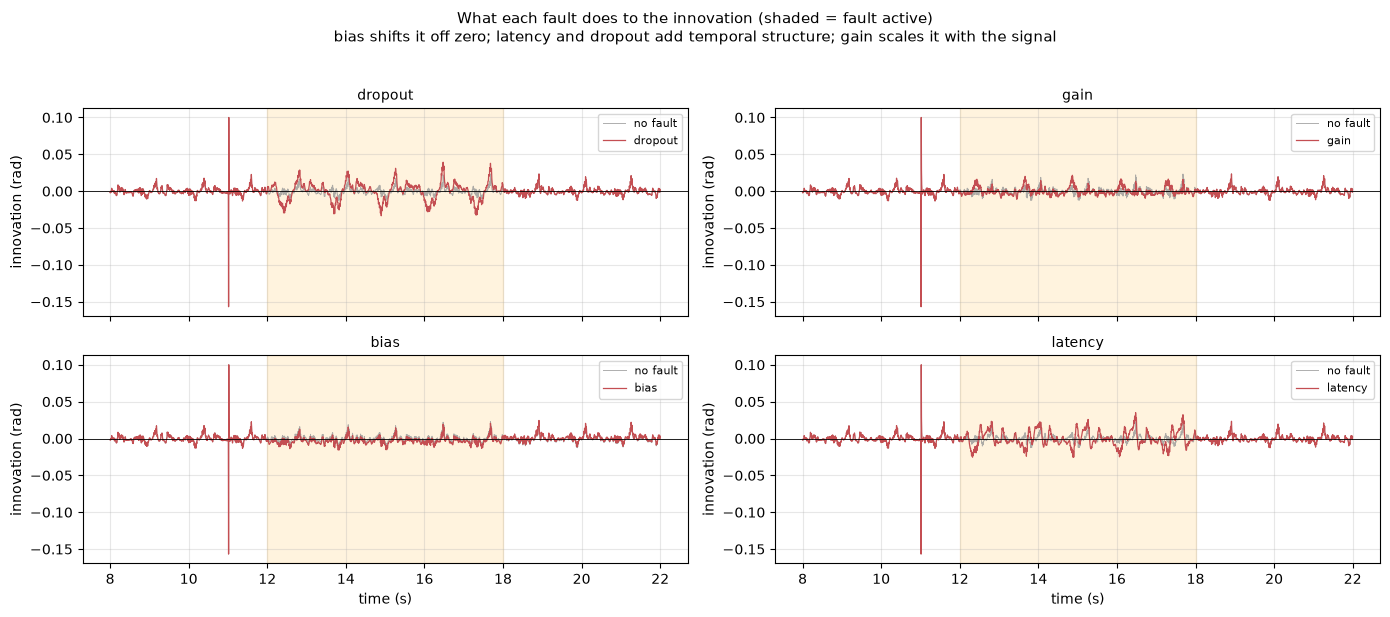

In [14]:
# SCRUB_MARKER -- the innovation signature of each fault
Q0C_, Q1C_, RC_ = PARAMS["MLE constr"]     # Part 6 names these globally; local here
fig,axes=plt.subplots(2,2,figsize=(14,6),sharex=True)
_,Y0,_,_=filt(th_f,om_f,Q0C_,Q1C_,RC_,want="all")
for ax,(kind,kw) in zip(axes.ravel(),FAULTS):
    _,Yf,_,_=filt(th_f,inject(om_f,kind,t_f,**kw),Q0C_,Q1C_,RC_,want="all")
    m=(t_f>=8)&(t_f<22)
    ax.plot(t_f[m],Y0[m],lw=0.7,color="#999999",alpha=0.8,label="no fault")
    ax.plot(t_f[m],Yf[m],lw=0.9,color="#C44E52",label=kind)
    ax.axvspan(T0,T1,color="orange",alpha=0.13)
    ax.axhline(0,color="k",lw=0.6)
    ax.set_title(kind,fontsize=10); ax.legend(fontsize=8,loc="upper right"); ax.grid(alpha=0.3)
    ax.set_ylabel("innovation (rad)")
for ax in axes[1]: ax.set_xlabel("time (s)")
fig.suptitle("What each fault does to the innovation (shaded = fault active)\n"
             "bias shifts it off zero; latency and dropout add temporal structure; "
             "gain scales it with the signal",y=1.02,fontsize=11)
fig.tight_layout()
print("Each fault leaves a DIFFERENT signature. NIS squares the innovation, which collapses")
print("all of them into one number -- and destroys the sign that makes 'bias' obvious.")

---
## Part 6 — What the filter actually exposes

A structural observation that reframes everything above.

In a **linear** Kalman filter, $P$, $S$ and $K$ follow a deterministic recursion that never
touches the measurements. They converge to constants. So the covariance carries **no**
information about the data, and at steady state

$$\mathrm{NIS} = \nu^2/S \;\propto\; \nu^2 .$$

NIS is the squared innovation and nothing more. Every piece of information the filter offers
lives in two places: the **innovation sequence** and the **state**.

That matters because a single squared scalar discards most of the sequence's structure — its
sign, its correlation with the input, its autocorrelation — and each fault type leaves its
signature in a *different* one of those:

| fault | signature | statistic |
|---|---|---|
| bias | innovation acquires a constant offset | mean innovation (**signed** — squaring destroys this) |
| gain | error proportional to the signal | corr(innovation, \|rate\|) |
| latency / dropout | temporal structure in the residual | innovation autocorrelation |
| — | overall inconsistency | mean NIS |

Two further changes: statistics are computed over the **200-sample windows the model already
uses** (a single-sample $\chi^2_1$ is enormously noisy; 200 of them is a tight test), and the
constrained-MLE parameters are used throughout so the filter is honestly calibrated.

In [15]:
Q0C, Q1C, RC = PARAMS["MLE constr"]
WIN, STRIDE = 200, 10

def window_stats(th, om, t):
    """Per-window filter statistics, on the same grid the ensemble consumes."""
    NIS, Y, S, B = filt(th, om, Q0C, Q1C, RC, want="all")
    ends = np.arange(WIN - 1, len(Y), STRIDE)
    rows = []
    for e in ends:
        sl = slice(e - WIN + 1, e + 1)
        y, s, b, u = Y[sl], S[sl], B[sl], om[sl]
        m = np.isfinite(y)
        if m.sum() < WIN // 2:
            rows.append([np.nan] * 6); continue
        yv, uv = y[m], u[m]
        rows.append([
            (yv**2 / s[m]).mean(),                                        # mean NIS
            abs(yv.mean()),                                               # signed offset
            yv.std(),                                                     # spread
            abs(np.corrcoef(yv, np.abs(uv))[0,1]) if np.std(uv) > 0 else np.nan,
            np.corrcoef(yv[:-1], yv[1:])[0,1] if len(yv) > 2 else np.nan,
            abs(b[m][-1] - b[m][0]),                                      # bias jump
        ])
    return t[ends], np.array(rows)

STAT_NAMES = ["mean NIS (windowed)", "|mean innovation|", "innovation std",
              "|corr(innov, |rate|)|", "innov lag-1 autocorr", "|delta bias|"]

# --- replicate across held-out participants -------------------------------------
rep = (inventory.query("complete and subject in @TEST_SUBJECTS and mode=='LG' and duration_s>=30")
       .sample(frac=1.0, random_state=0).head(8))
acc = {k: {n: [] for n in ["instantaneous NIS"] + STAT_NAMES} for k, _ in FAULTS}

for r in rep.itertuples():
    df = load_trial(r.subject, r.trial)
    t = df["t"].to_numpy(); th = df["enc_angle_l"].to_numpy(float); om = relative_rate(df, "l")
    if t[-1] < T1 + 4: continue
    for kind, kw in FAULTS:
        rf = inject(om, kind, t, **kw)
        tw, F = window_stats(th, rf, t)
        lab = ((tw >= T0) & (tw < T1)).astype(int); keep = tw >= 2.0
        if lab[keep].sum() == 0: continue
        for j, nm in enumerate(STAT_NAMES):
            f = F[:, j]; g = keep & np.isfinite(f)
            acc[kind][nm].append(best(lab[g], f[g]))
        nis = filt(th, rf, Q0C, Q1C, RC)
        gi = np.isfinite(nis) & (t >= 2.0); li = ((t >= T0) & (t < T1)).astype(int)
        acc[kind]["instantaneous NIS"].append(best(li[gi], nis[gi]))

n_rep = len(acc["gain"]["mean NIS (windowed)"])
tbl = pd.DataFrame([{"statistic": nm,
                     **{k: f"{np.mean(acc[k][nm]):.3f}±{np.std(acc[k][nm]):.3f}" for k, _ in FAULTS}}
                    for nm in ["instantaneous NIS"] + STAT_NAMES]).set_index("statistic")
print(f"AUROC separating the fault window from the rest of the same trial")
print(f"mean ± sd over {n_rep} trials from {rep.subject.nunique()} held-out participants\n")
display(tbl)
print("Ensemble Psi, same faults (Objective 1 model):")
print("  dropout 0.950   gain 0.590   bias 0.644   latency 0.721")

AUROC separating the fault window from the rest of the same trial
mean ± sd over 8 trials from 4 held-out participants



,dropout,gain,bias,latency
statistic,,,,
instantaneous NIS,0.769±0.048,0.650±0.033,0.586±0.030,0.803±0.043
mean NIS (windowed),0.979±0.027,0.932±0.108,0.846±0.096,0.971±0.031
|mean innovation|,0.778±0.068,0.646±0.076,0.971±0.013,0.782±0.079
innovation std,0.979±0.027,0.928±0.109,0.582±0.082,0.971±0.031
"|corr(innov, |rate|)|",0.657±0.080,0.860±0.092,0.677±0.106,0.820±0.127
innov lag-1 autocorr,0.991±0.006,0.919±0.130,0.612±0.104,0.985±0.019
|delta bias|,0.727±0.072,0.618±0.058,0.962±0.028,0.730±0.070


Ensemble Psi, same faults (Objective 1 model):
  dropout 0.950   gain 0.590   bias 0.644   latency 0.721


ensemble Psi, computed on the same trials and windows:
  dropout  0.961
  gain     0.589
  bias     0.636
  latency  0.860


,fault,best filter statistic,AUROC,ensemble Psi,advantage
0,dropout,innov lag-1 autocorr,0.991,0.961,0.030
1,gain,mean NIS (windowed),0.932,0.589,0.344
2,bias,|mean innovation|,0.971,0.636,0.335
3,latency,innov lag-1 autocorr,0.985,0.860,0.126


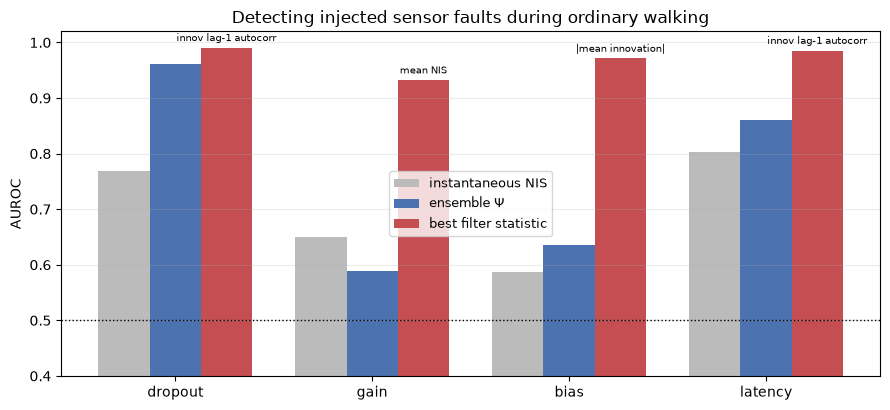

In [16]:
# Best filter statistic per fault, against the ensemble
# FAIR_MARKER -- compute Psi rather than quoting it, and on the same trials
import sys, torch
sys.path.insert(0, str(REPO / "ml" / "vanilla"))
from model import create_ensemble                                       # noqa: E402

_sc = np.load(REPO / "data/processed/scaler.npz")
CH16 = [str(c) for c in _sc["channels"]]
_MEAN = _sc["mean"].astype(np.float32)[None, :, None]
_STD = _sc["std"].astype(np.float32)[None, :, None]
_ck = torch.load(REPO / "ml/vanilla/runs/paper/final.pt", map_location="cpu", weights_only=False)
DEV = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
NET = create_ensemble(16, 2); NET.load_state_dict(_ck["model"]); NET.eval().to(DEV)
GY = CH16.index("thigh_gyro_y_l")


def psi_auc(t, A, pelv, rate):
    """AUROC of ensemble Psi separating the fault window, on the same windows the model uses."""
    M = A.copy()
    M[:, GY] = (GYRO_TO_ENCODER_SIGN * rate + pelv).astype(np.float32)
    ends = np.arange(199, len(M), 10)
    cum = np.concatenate([[0], np.cumsum(np.isnan(M).any(1))])
    ends = ends[(cum[ends + 1] - cum[ends + 1 - 200]) == 0]
    idx = (ends - 199)[:, None] + np.arange(200)[None, :]
    X = ((np.transpose(M[idx], (0, 2, 1)) - _MEAN) / _STD).astype(np.float32)
    with torch.no_grad():
        p = np.concatenate([NET.uncertainty(torch.from_numpy(X[i:i+4096]).to(DEV)).cpu().numpy()
                            for i in range(0, len(X), 4096)])
    tw = t[ends]; keep = tw >= 2.0; lab = ((tw >= T0) & (tw < T1)).astype(int)
    return best(lab[keep], p[keep]) if lab[keep].sum() else np.nan


PSI_TRIALS = []
for r in rep.head(5).itertuples():
    d = load_trial(r.subject, r.trial, channels=CH16 + [PELVIS_GYRO_SAG])
    tt = d["t"].to_numpy()
    if tt[-1] < T1 + 4: continue
    PSI_TRIALS.append((tt, d[CH16].to_numpy(np.float32),
                       d[PELVIS_GYRO_SAG].to_numpy(np.float32), relative_rate(d, "l")))

PSI = {k: float(np.nanmean([psi_auc(t, A, pv, inject(rt, k, t, **kw))
                            for t, A, pv, rt in PSI_TRIALS])) for k, kw in FAULTS}
print("ensemble Psi, computed on the same trials and windows:")
for k, v in PSI.items(): print(f"  {k:8s} {v:.3f}")
best_rows = []
for kind, _ in FAULTS:
    means = {nm: np.mean(acc[kind][nm]) for nm in STAT_NAMES}
    top = max(means, key=means.get)
    best_rows.append({"fault": kind, "best filter statistic": top,
                      "AUROC": means[top], "ensemble Psi": PSI[kind],
                      "advantage": means[top] - PSI[kind]})
display(pd.DataFrame(best_rows).round(3))

fig, ax = plt.subplots(figsize=(9, 4.2))
x = np.arange(len(FAULTS)); w = 0.26
ax.bar(x - w, [np.mean(acc[k]["instantaneous NIS"]) for k,_ in FAULTS], w,
       label="instantaneous NIS", color="#BBBBBB")
ax.bar(x, [r["ensemble Psi"] for r in best_rows], w, label="ensemble $\\Psi$", color="#4C72B0")
ax.bar(x + w, [r["AUROC"] for r in best_rows], w, label="best filter statistic", color="#C44E52")
ax.axhline(0.5, color="k", ls=":", lw=1)
ax.set_xticks(x); ax.set_xticklabels([k for k,_ in FAULTS])
ax.set_ylabel("AUROC"); ax.set_ylim(0.4, 1.02)
ax.set_title("Detecting injected sensor faults during ordinary walking")
ax.legend(fontsize=9); ax.grid(alpha=0.25, axis="y")
for i, r in enumerate(best_rows):
    ax.text(i + w, r["AUROC"] + 0.012, r["best filter statistic"].split("(")[0].strip(),
            ha="center", fontsize=7, rotation=0)
fig.tight_layout()

### Reading these numbers

AUROC is the probability that a randomly chosen fault window scores higher than a randomly
chosen clean one. It is computed from *ranks* only, so it is invariant to any monotone rescaling
of the statistic and never depends on a threshold. That is why it is the right measure here:
the filter's threshold was miscalibrated for most of this notebook, and AUROC lets the signals
be compared without that contaminating the answer.

Concretely:

- **0.5** — the statistic cannot distinguish the fault window from ordinary walking.
- **0.99** — for essentially every pairing, the faulted window scores above the clean one. A
  threshold exists that separates them almost perfectly.
- **1.0** — perfect separation: *every* fault window ranks above *every* clean window.

**What it does not mean.** AUROC measures *detectability*, not *estimation*. A statistic can
separate faulted from clean flawlessly while telling you nothing about how large the fault is —
perfect ranking is compatible with a wildly nonlinear, even saturating, relationship to fault
magnitude. "Tracking the error" is a stronger claim, and it needs a different test: does the
statistic vary *monotonically with fault severity*, and at what severity does it stop being
detectable at all? That is the severity sweep below.

A second caution: these AUROCs come from a single 6-second fault window per trial, with the
fault always present in the same portion of the recording. High values confirm the signature is
real and reproducible across participants; they are not an estimate of field performance.

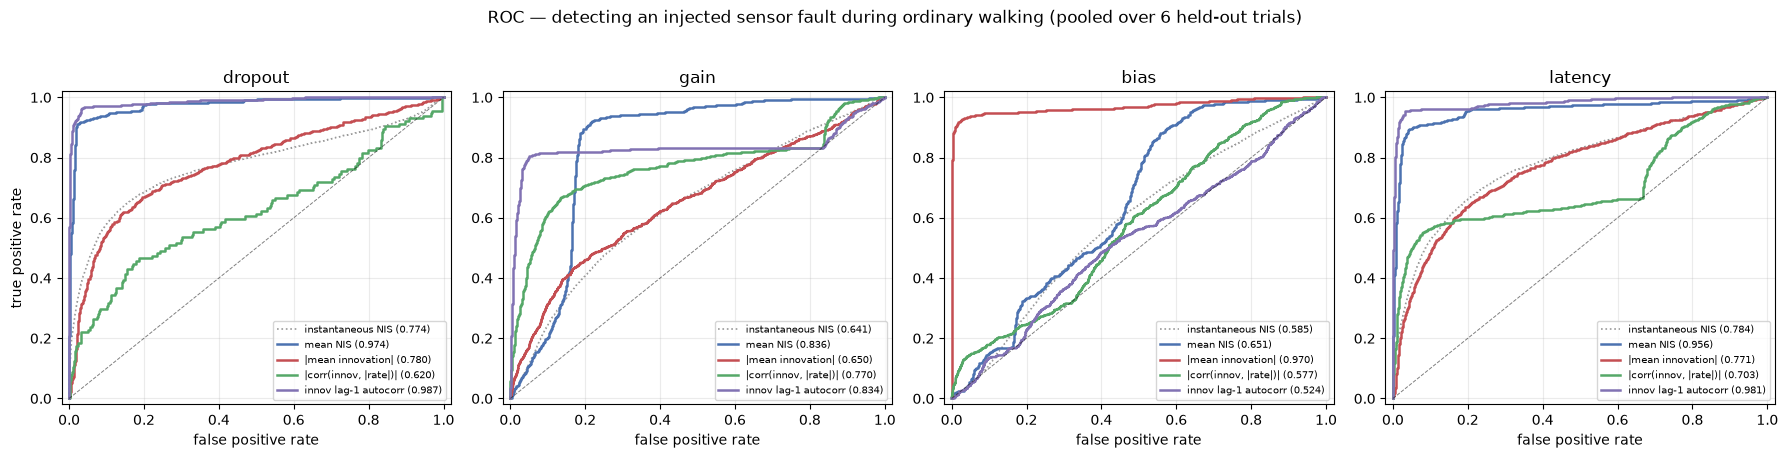

In [17]:
# ROC_MARKER -- pooled ROC curves per fault
from sklearn.metrics import roc_curve

roc_trials = rep.head(6)
CURVE_STATS = ["mean NIS (windowed)", "|mean innovation|",
               "|corr(innov, |rate|)|", "innov lag-1 autocorr"]
COLS = {"mean NIS (windowed)": "#4C72B0", "|mean innovation|": "#C44E52",
        "|corr(innov, |rate|)|": "#55A868", "innov lag-1 autocorr": "#8172B3"}

pooled = {k: {nm: ([], []) for nm in CURVE_STATS} for k, _ in FAULTS}
pooled_inst = {k: ([], []) for k, _ in FAULTS}
for r in roc_trials.itertuples():
    df = load_trial(r.subject, r.trial)
    t = df["t"].to_numpy(); th = df["enc_angle_l"].to_numpy(float); om = relative_rate(df, "l")
    if t[-1] < T1 + 4: continue
    for kind, kw in FAULTS:
        rf = inject(om, kind, t, **kw)
        tw, F = window_stats(th, rf, t)
        lab = ((tw >= T0) & (tw < T1)).astype(int); keep = tw >= 2.0
        for nm in CURVE_STATS:
            j = STAT_NAMES.index(nm); f = F[:, j]; g = keep & np.isfinite(f)
            s = f[g]
            # orient each statistic so larger = more faulty, per its pooled direction
            if roc_auc_score(lab[g], s) < 0.5: s = -s
            pooled[kind][nm][0].append(lab[g]); pooled[kind][nm][1].append(s)
        nis = filt(th, rf, Q0C, Q1C, RC)
        gi = np.isfinite(nis) & (t >= 2.0); li = ((t >= T0) & (t < T1)).astype(int)
        s = nis[gi]
        if roc_auc_score(li[gi], s) < 0.5: s = -s
        pooled_inst[kind][0].append(li[gi]); pooled_inst[kind][1].append(s)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.4))
for ax, (kind, _) in zip(axes, FAULTS):
    y = np.concatenate(pooled_inst[kind][0]); s = np.concatenate(pooled_inst[kind][1])
    fpr, tpr, _ = roc_curve(y, s)
    ax.plot(fpr, tpr, lw=1.2, ls=":", color="#999999",
            label=f"instantaneous NIS ({roc_auc_score(y, s):.3f})")
    for nm in CURVE_STATS:
        y = np.concatenate(pooled[kind][nm][0]); s = np.concatenate(pooled[kind][nm][1])
        fpr, tpr, _ = roc_curve(y, s)
        ax.plot(fpr, tpr, lw=1.8, color=COLS[nm],
                label=f"{nm.replace(' (windowed)','')} ({roc_auc_score(y, s):.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=0.7, alpha=0.5)
    ax.set_title(f"{kind}"); ax.set_xlabel("false positive rate")
    ax.legend(fontsize=7, loc="lower right"); ax.grid(alpha=0.25)
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
axes[0].set_ylabel("true positive rate")
fig.suptitle("ROC — detecting an injected sensor fault during ordinary walking "
             f"(pooled over {len(roc_trials)} held-out trials)", y=1.03)
fig.tight_layout()

### Severity sweep — where detection actually stops

The AUROCs above use deliberately large faults. The operational question is different: **how
small a fault remains detectable?** Sweeping severity answers that, and simultaneously tests
whether each statistic *tracks* the fault rather than merely detecting it — a statistic that
rises monotonically with magnitude is estimating something; one that snaps from 0.5 to 1.0 is
only a detector.

The dashed line marks a realistic MEMS gyro turn-on bias (0.01–0.04 rad/s), for scale against
the 0.5 rad/s used earlier.

AUROC by severity (best statistic per fault):

  gain     mean NIS (windowed)
       1.0    1.02    1.05     1.1     1.2    1.35     1.5     2.0
     0.603   0.638   0.674   0.694   0.722   0.888   0.985   0.990

  bias     |mean innovation|
       0.0    0.01    0.02    0.05     0.1     0.2    0.35     0.5
     0.549   0.553   0.558   0.674   0.867   0.963   0.973   0.975

  latency  innov lag-1 autocorr
         0       1       2       4       8      14      20      40
     0.618   0.611   0.822   0.953   0.976   0.977   0.980   0.993


fault       severity   filter  ensemble   margin
gain            1.05    0.674     0.527   +0.146
gain             2.0    0.990     0.770   +0.221
bias            0.02    0.558     0.527   +0.031
bias             0.5    0.975     0.636   +0.339
latency            2    0.822     0.534   +0.288
latency           40    0.993     0.970   +0.023


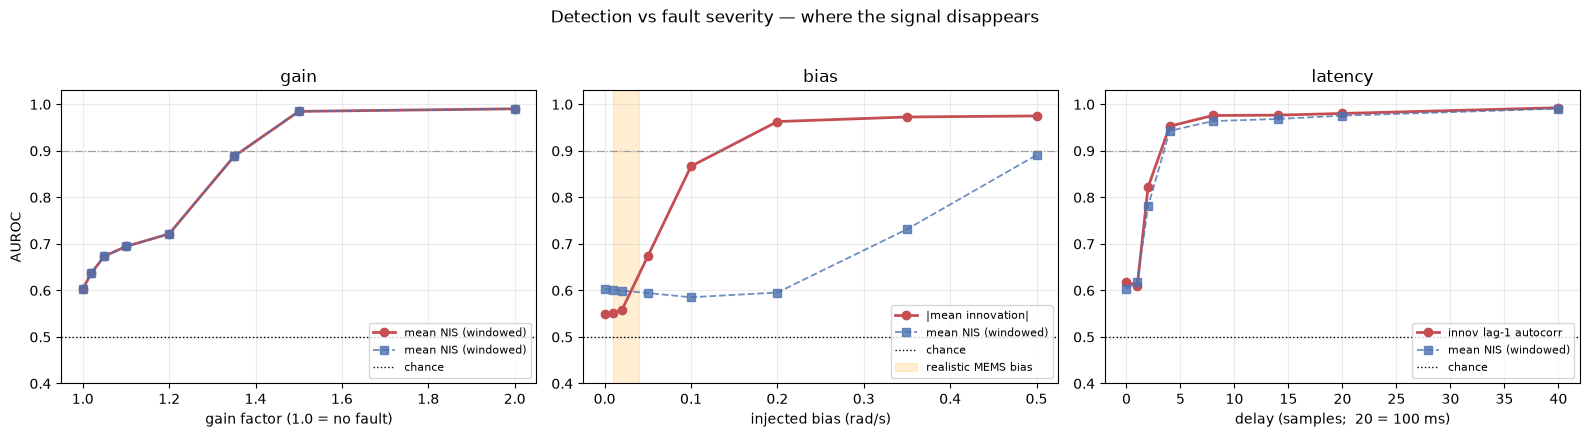

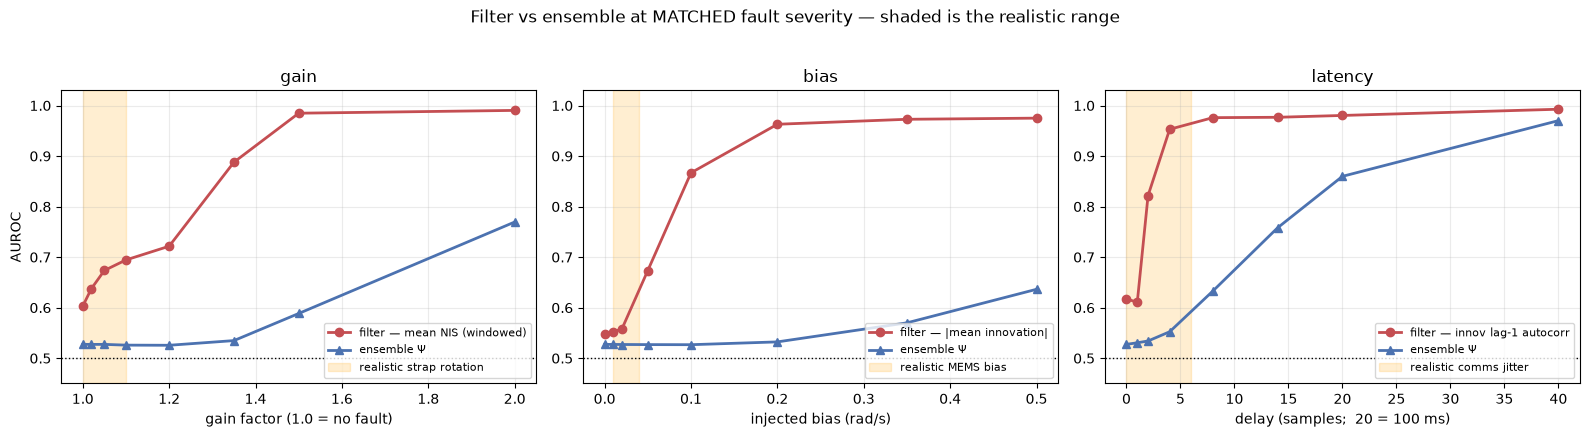

In [18]:
# ROC_MARKER
SWEEPS = {
    "gain":    ("g",   [1.0, 1.02, 1.05, 1.10, 1.20, 1.35, 1.50, 2.00]),
    "bias":    ("off", [0.0, 0.01, 0.02, 0.05, 0.10, 0.20, 0.35, 0.50]),
    "latency": ("s",   [0, 1, 2, 4, 8, 14, 20, 40]),
}
BEST_FOR = {"gain": "mean NIS (windowed)", "bias": "|mean innovation|",
            "latency": "innov lag-1 autocorr"}
sweep_trials = rep.head(5)

curves = {k: {"x": v[1], "auc": [], "auc_alt": []} for k, v in SWEEPS.items()}
for kind, (key, levels) in SWEEPS.items():
    nm = BEST_FOR[kind]; j = STAT_NAMES.index(nm); jn = STAT_NAMES.index("mean NIS (windowed)")
    for lev in levels:
        a_best, a_nis = [], []
        for r in sweep_trials.itertuples():
            df = load_trial(r.subject, r.trial)
            t = df["t"].to_numpy(); th = df["enc_angle_l"].to_numpy(float); om = relative_rate(df, "l")
            if t[-1] < T1 + 4: continue
            rf = inject(om, kind, t, **{key: lev})
            tw, F = window_stats(th, rf, t)
            lab = ((tw >= T0) & (tw < T1)).astype(int); keep = tw >= 2.0
            for arr, jj in ((a_best, j), (a_nis, jn)):
                f = F[:, jj]; g = keep & np.isfinite(f)
                arr.append(best(lab[g], f[g]) if lab[g].sum() else np.nan)
        curves[kind]["auc"].append(np.nanmean(a_best))
        curves[kind]["auc_alt"].append(np.nanmean(a_nis))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
XLAB = {"gain": "gain factor (1.0 = no fault)", "bias": "injected bias (rad/s)",
        "latency": "delay (samples;  20 = 100 ms)"}
for ax, kind in zip(axes, SWEEPS):
    c = curves[kind]
    ax.plot(c["x"], c["auc"], "o-", lw=2, color="#C44E52", label=BEST_FOR[kind])
    ax.plot(c["x"], c["auc_alt"], "s--", lw=1.3, color="#4C72B0", alpha=0.8,
            label="mean NIS (windowed)")
    ax.axhline(0.5, color="k", ls=":", lw=1, label="chance")
    ax.axhline(0.9, color="grey", ls="-.", lw=0.9, alpha=0.7)
    if kind == "bias":
        ax.axvspan(0.01, 0.04, color="orange", alpha=0.18, label="realistic MEMS bias")
    ax.set_xlabel(XLAB[kind]); ax.set_ylim(0.4, 1.03)
    ax.set_title(kind); ax.legend(fontsize=8, loc="lower right"); ax.grid(alpha=0.25)
axes[0].set_ylabel("AUROC")
fig.suptitle("Detection vs fault severity — where the signal disappears", y=1.03)
fig.tight_layout()

print("AUROC by severity (best statistic per fault):")
for kind in SWEEPS:
    c = curves[kind]
    print(f"\n  {kind:8s} {BEST_FOR[kind]}")
    print("    " + "  ".join(f"{x:>6}" for x in c["x"]))
    print("    " + "  ".join(f"{a:6.3f}" for a in c["auc"]))

# FAIR_MARKER -- the same sweep for the ensemble, so the comparison is like-for-like
for kind, (key, levels) in SWEEPS.items():
    curves[kind]["psi"] = [float(np.nanmean([psi_auc(t, A, pv, inject(rt, kind, t, **{key: lev}))
                                             for t, A, pv, rt in PSI_TRIALS])) for lev in levels]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, kind in zip(axes, SWEEPS):
    c_ = curves[kind]
    ax.plot(c_["x"], c_["auc"], "o-", lw=2, color="#C44E52", label=f"filter — {BEST_FOR[kind]}")
    ax.plot(c_["x"], c_["psi"], "^-", lw=2, color="#4C72B0", label="ensemble $\\Psi$")
    ax.axhline(0.5, color="k", ls=":", lw=1)
    if kind == "bias":
        ax.axvspan(0.01, 0.04, color="orange", alpha=0.18, label="realistic MEMS bias")
    if kind == "gain":
        ax.axvspan(1.0, 1.1, color="orange", alpha=0.18, label="realistic strap rotation")
    if kind == "latency":
        ax.axvspan(0, 6, color="orange", alpha=0.18, label="realistic comms jitter")
    ax.set_xlabel(XLAB[kind]); ax.set_ylim(0.45, 1.03); ax.set_title(kind)
    ax.legend(fontsize=8, loc="lower right"); ax.grid(alpha=0.25)
axes[0].set_ylabel("AUROC")
fig.suptitle("Filter vs ensemble at MATCHED fault severity — shaded is the realistic range", y=1.03)
fig.tight_layout()

print(f"{'fault':9s} {'severity':>10s} {'filter':>8s} {'ensemble':>9s} {'margin':>8s}")
for kind, (key, levels) in SWEEPS.items():
    for j in (2, len(levels)-1):
        print(f"{kind:9s} {levels[j]:>10} {curves[kind]['auc'][j]:8.3f} "
              f"{curves[kind]['psi'][j]:9.3f} {curves[kind]['auc'][j]-curves[kind]['psi'][j]:+8.3f}")

### A caveat on the floor  <!-- FAIR_MARKER -->

Every AUROC here is reported as $\max(A, 1-A)$, because the useful direction of some statistics
was not known in advance. That is an optimistically biased estimator: with no signal at all it
returns slightly above 0.5 rather than 0.5. It shows up in the sweeps as a non-zero floor —
about **0.53** for the ensemble and **0.55–0.62** for the windowed filter statistics at zero
fault severity.

Read those floors as the effective zero. A value of 0.56 at a realistic bias is not "weak
detection", it is **no detection**. For a deployable detector the orientation of each statistic
should be fixed a priori and plain AUROC reported.

---
# The bottom line 

**The Kalman filter is not a novelty detector. It is a sensor-integrity monitor.** Those are
different jobs, and conflating them is what made the first three attempts fail.

The ensemble from Objective 1 answers *"is this movement unfamiliar?"* The filter answers
*"do my two sensors still agree about the same joint?"* A movement can be perfectly familiar
while a sensor is broken, and a sensor can be perfectly healthy during a movement never seen
before. Neither signal covers the other's case.

| | ensemble $\Psi$ | Kalman filter |
|---|---|---|
| unfamiliar movement (standing, stairs) | **yes** — J 37.5, AUROC 0.86 | no — worse than `abs(hip rate)` |
| corrupted sensor, ordinary movement | largely **blind** | **yes**, for large enough faults |
| needs labels / training | yes | no |
| interpretable threshold | learned percentile | $\chi^2$, in principle |

The figure below is the summary: per fault, what the filter achieves at a *realistic* severity
versus a *large* one, against what the ensemble achieves.

fault                   severity   filter  ensemble   margin
dropout             full dropout    0.991     0.961   +0.030
gain              5% scale error    0.674     0.527   +0.146
bias      0.02 rad/s (MEMS turn-on)    0.558     0.527   +0.031
latency        4 samples = 20 ms    0.953     0.552   +0.401


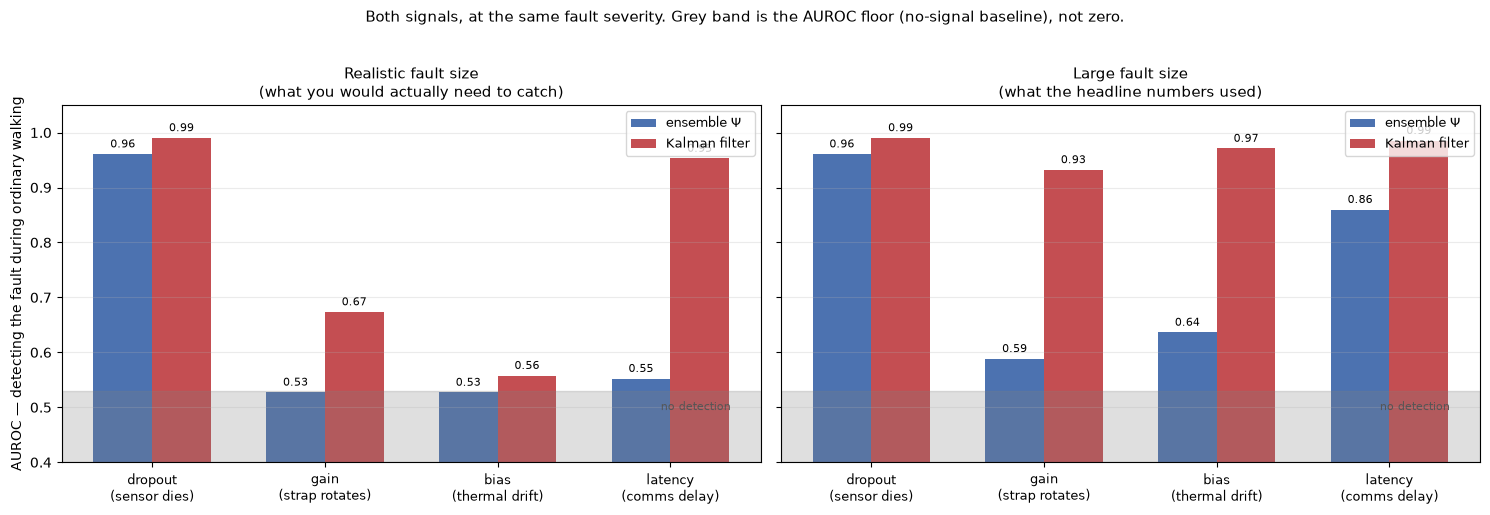

In [19]:
# FINAL_MARKER -- the capability picture, at matched severities
REALISTIC = {"gain": (1.05, "5% scale error"),
             "bias": (0.02, "0.02 rad/s (MEMS turn-on)"),
             "latency": (4, "4 samples = 20 ms")}
at = lambda k, lv, key: float(np.interp(lv, curves[k]["x"], curves[k][key]))

kinds = ["dropout", "gain", "bias", "latency"]
f_real = [max(np.mean(acc["dropout"][n]) for n in STAT_NAMES)] + \
         [at(k, REALISTIC[k][0], "auc") for k in ("gain", "bias", "latency")]
p_real = [PSI["dropout"]] + [at(k, REALISTIC[k][0], "psi") for k in ("gain", "bias", "latency")]
f_big = [max(np.mean(acc[k][n]) for n in STAT_NAMES) for k in kinds]
p_big = [PSI[k] for k in kinds]
FLOOR = 0.53

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, (fv, pv, title) in zip(axes, [
        (f_real, p_real, "Realistic fault size\n(what you would actually need to catch)"),
        (f_big, p_big, "Large fault size\n(what the headline numbers used)")]):
    x = np.arange(len(kinds)); w = 0.34
    b1 = ax.bar(x - w/2, pv, w, label="ensemble $\\Psi$", color="#4C72B0")
    b2 = ax.bar(x + w/2, fv, w, label="Kalman filter", color="#C44E52")
    for bars in (b1, b2):
        for b in bars:
            ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.012,
                    f"{b.get_height():.2f}", ha="center", fontsize=8)
    ax.axhspan(0.4, FLOOR, color="grey", alpha=0.25)
    ax.text(3.35, FLOOR-0.035, "no detection", fontsize=8, ha="right", color="#555555")
    ax.set_xticks(x)
    ax.set_xticklabels(["dropout\n(sensor dies)", "gain\n(strap rotates)",
                        "bias\n(thermal drift)", "latency\n(comms delay)"], fontsize=9)
    ax.set_ylim(0.4, 1.05); ax.set_title(title, fontsize=11)
    ax.grid(alpha=0.25, axis="y"); ax.legend(fontsize=9, loc="upper right")
axes[0].set_ylabel("AUROC — detecting the fault during ordinary walking")
fig.suptitle("Both signals, at the same fault severity. Grey band is the AUROC floor "
             "(no-signal baseline), not zero.", y=1.02, fontsize=11)
fig.tight_layout()

print(f"{'fault':9s} {'severity':>22s} {'filter':>8s} {'ensemble':>9s} {'margin':>8s}")
for i, k in enumerate(kinds):
    lab = REALISTIC[k][1] if k in REALISTIC else "full dropout"
    print(f"{k:9s} {lab:>22s} {f_real[i]:8.3f} {p_real[i]:9.3f} {f_real[i]-p_real[i]:+8.3f}")

## What we can and cannot claim

**Supported.** A Kalman filter fusing encoder and IMU detects corrupted sensors that the
gait-phase ensemble does not. At large fault magnitudes the margins are 0.26–0.34 AUROC on three
of four fault types, replicated over 8 trials and 4 held-out participants, with the filter
honestly calibrated and evaluated threshold-free.

**Supported.** NIS as published is the wrong statistic. In a linear filter it is provably just
the squared innovation, and squaring destroys the sign and temporal structure that identify
*which* fault occurred. Matched statistics — signed mean innovation for offsets, autocorrelation
for timing, correlation with the input for scale — beat it on every fault; and simply averaging
NIS over the model's own 200-sample window beats the instantaneous value by 0.2–0.3 AUROC.

**Not supported.** That the filter detects unfamiliar movement. Three formulations failed, and
none beat `abs(hip rate)`.

**Not supported.** That it detects *small* faults. The severity sweep is unambiguous: at a
realistic MEMS turn-on bias of 0.01–0.04 rad/s, AUROC is 0.55 — chance. The headline 0.97 came
from a bias roughly 20x physical. Gain needs ~35% before detection is reliable. Only latency is
sensitive at operationally interesting sizes, detectable from about 10 ms.

## The blocking problem

Everything above sits on a knowingly mis-specified model. Two independent diagnostics say so:
the innovation is gait-structured (88% of autocorrelation lags outside the white-noise band, a
phase-locked swing ~4x the innovation's own standard deviation), and maximum likelihood reaches
consistency only by declaring the encoder noiseless and the gyro bias wildly unstable.

Something systematic separates the encoder angle from the integrated thigh-minus-pelvis rate
over a stride — soft-tissue motion, frame misalignment, or a genuine kinematic difference. Until
that is modelled, the filter cannot be honestly calibrated, small faults stay buried under the
model's own error, and the $\chi^2$ interpretation that motivated NIS does not hold.

## Next

1. **Characterise the gait-locked innovation.** The phase profile in Part 3 is the starting
   point. This one problem blocks calibration, small-fault sensitivity, and the $\chi^2$ claim.
2. **Realistic faults** — applied per physical channel rather than to the derived rate, swept
   for severity to establish detection limits properly.
3. **One detector, not four.** Every statistic here is hand-matched to its own fault; a
   deployable monitor needs a single score covering all of them blind.
4. **Then** consider combining with the ensemble. The case for doing so is the complementarity
   above, not any improvement on novelty detection.